Khởi tạo và Tải dữ liệu

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import shap
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier

df = pd.read_csv(r"C:\Ki_4\Domain Banking\Financial Transactions\data\Big_Query_Fetched.csv")
display(df.head())
display(df.isnull().sum())

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,errors,target,current_age,gender,yearly_income,total_debt,credit_score,card_brand,card_type,mcc_description
0,16029274,2015-05-01 14:58:00,1492,4818,364.79,Online Transaction,60152,ONLINE,Online/International,Online/International,...,No Error,1,63,Female,56635,13015,786,Visa,Credit,Steelworks
1,16402126,2015-07-20 10:00:00,1542,2906,183.56,Online Transaction,5594,ONLINE,Online/International,Online/International,...,No Error,1,46,Female,55565,34039,731,Mastercard,Debit (Prepaid),Steel Products Manufacturing
2,17222818,2016-01-11 17:26:00,277,4264,25.44,Online Transaction,30497,ONLINE,Online/International,Online/International,...,No Error,1,46,Male,31739,81905,799,Mastercard,Debit,Coated and Laminated Products
3,8465827,2010-09-03 07:06:00,1699,2204,614.71,Online Transaction,47203,ONLINE,Online/International,Online/International,...,No Error,1,67,Female,52929,37514,737,Visa,Debit,Steel Drums and Barrels
4,20952333,2018-03-15 17:47:00,517,106,466.13,Chip Transaction,47203,Rome,Italy,Online/International,...,No Error,1,33,Male,24009,19085,811,Mastercard,Credit,Steel Drums and Barrels


id                 0
date               0
client_id          0
card_id            0
amount             0
use_chip           0
merchant_id        0
merchant_city      0
merchant_state     0
zip                0
mcc                0
errors             0
target             0
current_age        0
gender             0
yearly_income      0
total_debt         0
credit_score       0
card_brand         0
card_type          0
mcc_description    0
dtype: int64

Khám phá dữ liệu (EDA)

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
amount,113332.0,51.011845,108.265102,-500.0,1.76,9.48,31.85,71.0,122.42,179.8935,423.7473,4978.45
current_age,113332.0,54.257447,15.733996,23.0,35.00,43.00,52.00,64.0,78.00,84.0000,92.0000,101.00
yearly_income,113332.0,46355.373469,24412.788261,1.0,26511.00,32576.00,40867.00,53702.0,70673.00,87030.0000,141161.0000,280199.00
total_debt,113332.0,57378.984250,51937.544510,0.0,1433.00,16040.00,51428.00,84507.0,119670.00,146608.0000,231619.0000,461854.00
credit_score,113332.0,713.867443,65.598973,488.0,625.00,684.00,716.00,756.0,792.00,814.0000,850.0000,850.00


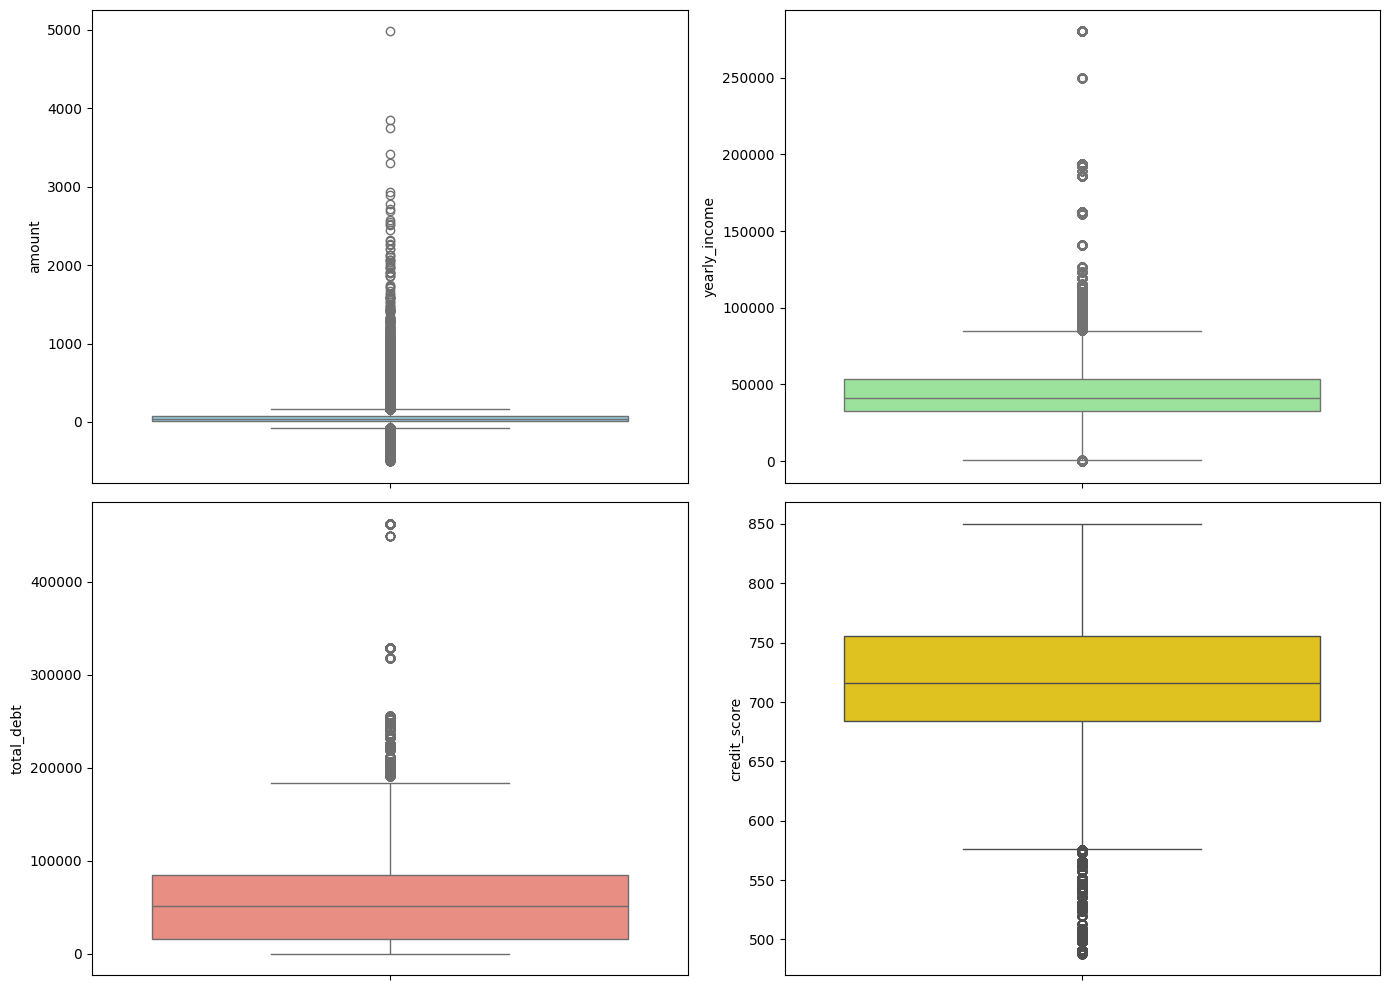

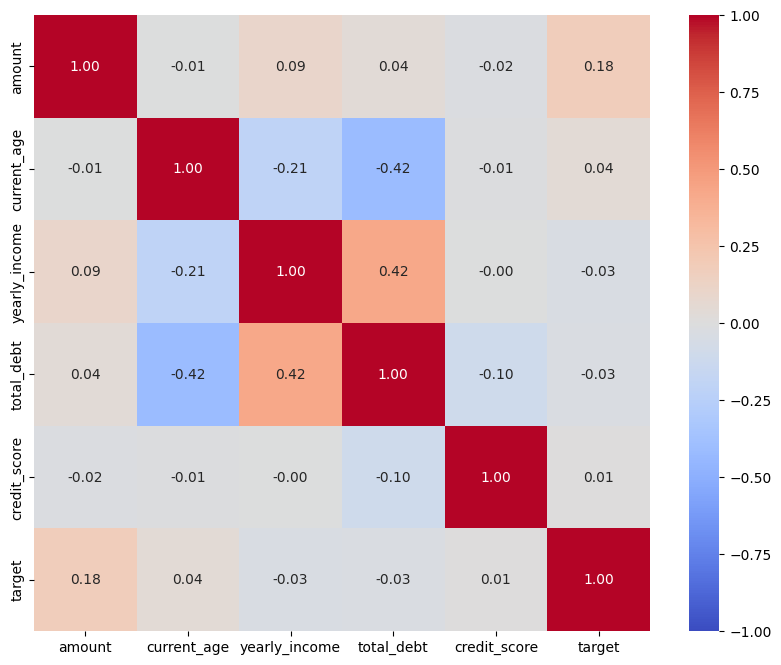

C:\Users\Admin\AppData\Local\Temp\ipykernel_29264\2957581068.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cardinality.values, y=cardinality.index, palette='viridis')


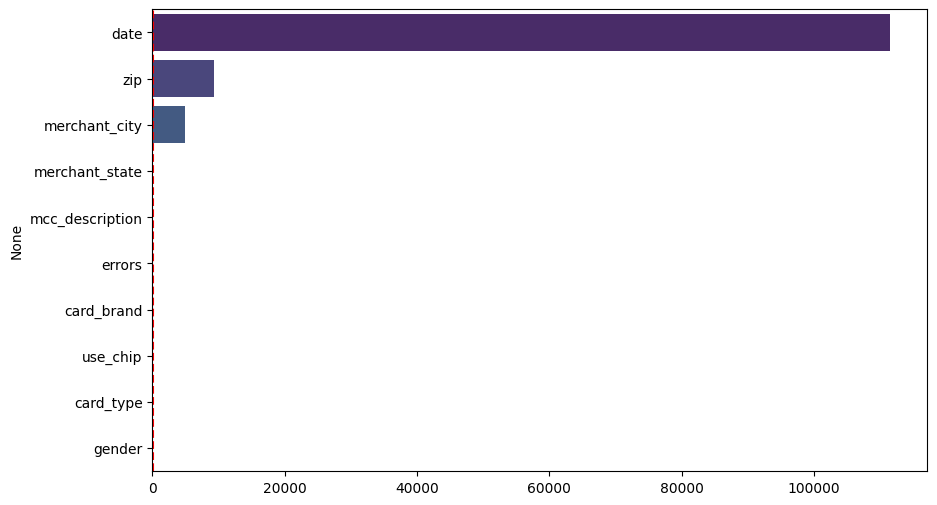

C:\Users\Admin\AppData\Local\Temp\ipykernel_29264\2957581068.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_fraud_rate.values, y=error_fraud_rate.index, palette='Reds_r')


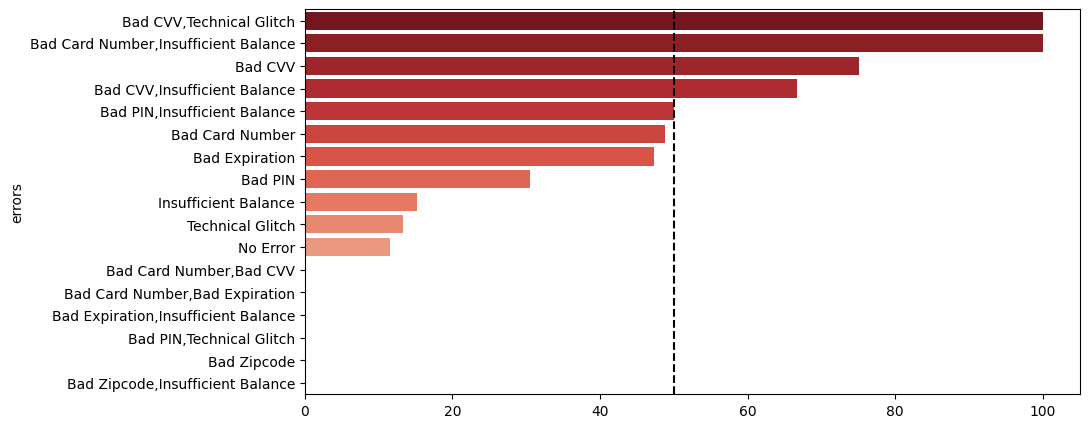

In [14]:
num_cols = ['amount', 'current_age', 'yearly_income', 'total_debt', 'credit_score']
display(df[num_cols].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(y=df['amount'], ax=axes[0, 0], color='skyblue')
sns.boxplot(y=df['yearly_income'], ax=axes[0, 1], color='lightgreen')
sns.boxplot(y=df['total_debt'], ax=axes[1, 0], color='salmon')
sns.boxplot(y=df['credit_score'], ax=axes[1, 1], color='gold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols + ['target']].corr(method='spearman'), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True)
plt.show()

cat_cols = df.select_dtypes(include=['object', 'string', 'category']).columns
cardinality = df[cat_cols].nunique().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=cardinality.values, y=cardinality.index, palette='viridis')
plt.axvline(x=100, color='red', linestyle='--')
plt.show()

error_fraud_rate = df.groupby('errors')['target'].mean().sort_values(ascending=False) * 100
plt.figure(figsize=(10, 5))
sns.barplot(x=error_fraud_rate.values, y=error_fraud_rate.index, palette='Reds_r')
plt.axvline(x=50, color='black', linestyle='--')
plt.show()

Xử lý dữ liệu và Feature Engineering

In [15]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['client_id', 'date']).reset_index(drop=True)

df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['is_senior_50_plus'] = (df['current_age'] >= 50).astype(int)
df['dti_ratio'] = df['total_debt'] / (df['yearly_income'] + 1)
df['hour_risk_tier'] = df['hour'].apply(lambda h: 2 if 10 <= h <= 13 else (0 if 0 <= h <= 5 else 1))
df['amount_vs_monthly_income'] = df['amount'] / ((df['yearly_income'] / 12) + 1)

df = df.set_index('date')
df['trans_count_24h'] = df.groupby('client_id')['amount'].rolling('24h', closed='left').count().reset_index(level=0, drop=True).fillna(0)
df['trans_sum_24h'] = df.groupby('client_id')['amount'].rolling('24h', closed='left').sum().reset_index(level=0, drop=True).fillna(0)
avg_30d = df.groupby('client_id')['amount'].rolling('30d', closed='left').mean().reset_index(level=0, drop=True)
df['amount_vs_30d_avg'] = (df['amount'] / (avg_30d + 1)).fillna(0)
df = df.reset_index()

cols_to_drop = ['id', 'card_id', 'merchant_id', 'date', 'merchant_city', 'zip', 'mcc', 'merchant_state', 'mcc_description', 'use_chip', 'errors']
df = df.drop(columns=cols_to_drop)

cat_cols = df.select_dtypes(include=['object', 'string']).columns
df[cat_cols] = df[cat_cols].astype('category')

Train/Test Split & Handling Inf

In [16]:
X = df.drop(columns=['target'])
y = df['target']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df['client_id']))

X_train = X.iloc[train_idx].drop(columns=['client_id']).replace([np.inf, -np.inf], 0)
X_test = X.iloc[test_idx].drop(columns=['client_id']).replace([np.inf, -np.inf], 0)
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (91308, 18)
Test shape: (22024, 18)


Base Model vs Feature Engineering Evaluation

In [17]:
engineered_features = ['trans_count_24h', 'amount_vs_monthly_income', 'amount_vs_30d_avg', 'hour_risk_tier', 'is_senior_50_plus', 'dti_ratio', 'hour', 'day_of_week', 'month', 'trans_sum_24h']
X_train_raw = X_train.drop(columns=engineered_features, errors='ignore')
X_test_raw = X_test.drop(columns=engineered_features, errors='ignore')

base_model = XGBClassifier(random_state=42, enable_categorical=True, tree_method='hist')
base_model.fit(X_train_raw, y_train)
print(f"PR-AUC (Base Model): {average_precision_score(y_test, base_model.predict_proba(X_test_raw)[:, 1]):.4f}")

fe_model = XGBClassifier(random_state=42, enable_categorical=True, tree_method='hist')
fe_model.fit(X_train, y_train)
print(f"PR-AUC (With Feature Engineering): {average_precision_score(y_test, fe_model.predict_proba(X_test)[:, 1]):.4f}")

PR-AUC (Base Model): 0.2946
PR-AUC (With Feature Engineering): 0.7607


Tối ưu siêu tham số cho Custom Focal Loss

In [18]:
def get_focal_loss_objective(alpha, gamma):
    def focal_loss_xgb(y_true, y_pred):
        p = np.clip(1.0 / (1.0 + np.exp(-y_pred)), 1e-5, 1.0 - 1e-5)
        g1 = -alpha * np.power(1 - p, gamma) * (1 - p - gamma * p * np.log(p))
        h1 = alpha * np.power(1 - p, gamma) * p * (1 - p) * (1 + gamma) 
        g0 = (1 - alpha) * np.power(p, gamma) * (p + gamma * (1 - p) * np.log(1 - p))
        h0 = (1 - alpha) * np.power(p, gamma) * p * (1 - p) * (1 + gamma)
        
        grad = np.where(y_true == 1, g1, g0)
        hess = np.maximum(np.where(y_true == 1, h1, h0), 1e-4)
        return grad, hess
    return focal_loss_xgb

alphas = [0.75, 0.85, 0.90, 0.95]
gammas = [1.0, 2.0, 3.0]
results = []

for alpha, gamma in itertools.product(alphas, gammas):
    model = XGBClassifier(objective=get_focal_loss_objective(alpha, gamma), random_state=42, enable_categorical=True, eval_metric='aucpr', n_estimators=200)
    model.fit(X_train, y_train)
    score = average_precision_score(y_test, model.predict_proba(X_test)[:, 1])
    results.append({'Alpha': alpha, 'Gamma': gamma, 'PR-AUC': score})
    print(f"Alpha={alpha:.2f}, Gamma={gamma:.1f} -> PR-AUC = {score:.4f}")

results_df = pd.DataFrame(results).sort_values(by='PR-AUC', ascending=False).reset_index(drop=True)
display(results_df.head(1))

Alpha=0.75, Gamma=1.0 -> PR-AUC = 0.7641
Alpha=0.75, Gamma=2.0 -> PR-AUC = 0.7625
Alpha=0.75, Gamma=3.0 -> PR-AUC = 0.7311
Alpha=0.85, Gamma=1.0 -> PR-AUC = 0.7609
Alpha=0.85, Gamma=2.0 -> PR-AUC = 0.7666
Alpha=0.85, Gamma=3.0 -> PR-AUC = 0.7456
Alpha=0.90, Gamma=1.0 -> PR-AUC = 0.7619
Alpha=0.90, Gamma=2.0 -> PR-AUC = 0.7660
Alpha=0.90, Gamma=3.0 -> PR-AUC = 0.7426
Alpha=0.95, Gamma=1.0 -> PR-AUC = 0.7635
Alpha=0.95, Gamma=2.0 -> PR-AUC = 0.7681
Alpha=0.95, Gamma=3.0 -> PR-AUC = 0.7587


,Alpha,Gamma,PR-AUC
0,0.95,2.0,0.768126


Tính toán chi phí kinh doanh (U-Curve)

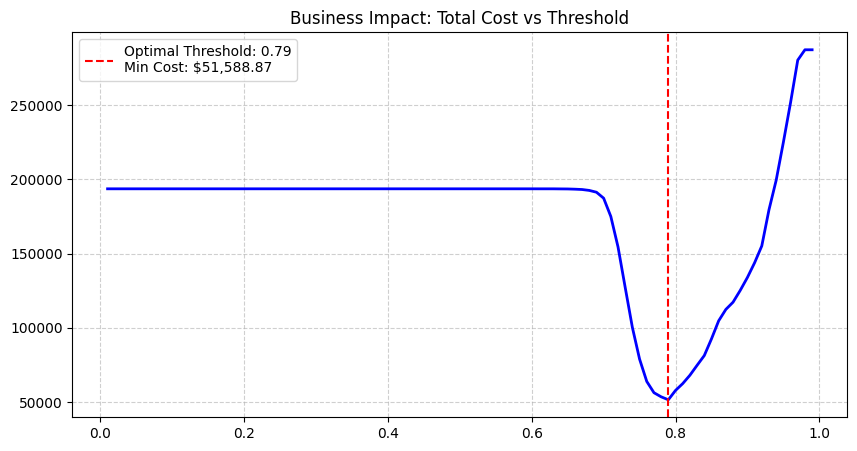

In [19]:
best_alpha = results_df.loc[0, 'Alpha']
best_gamma = results_df.loc[0, 'Gamma']

best_focal_model = XGBClassifier(objective=get_focal_loss_objective(best_alpha, best_gamma), random_state=42, enable_categorical=True)
best_focal_model.fit(X_train, y_train)
y_prob_best = best_focal_model.predict_proba(X_test)[:, 1]

COST_FP = 10 
amounts = X_test['amount'].values 
thresholds = np.arange(0.01, 1.00, 0.01)
costs = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_best >= thresh).astype(int)
    fp_cost = np.sum((y_pred_thresh == 1) & (y_test == 0)) * COST_FP
    fn_cost = np.sum(amounts[(y_pred_thresh == 0) & (y_test == 1)])
    costs.append(fp_cost + fn_cost)

min_cost = min(costs)
best_threshold = thresholds[costs.index(min_cost)]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs, color='blue', linewidth=2)
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Optimal Threshold: {best_threshold:.2f}\nMin Cost: ${min_cost:,.2f}')
plt.title('Business Impact: Total Cost vs Threshold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Mức độ giải thích của mô hình (SHAP)

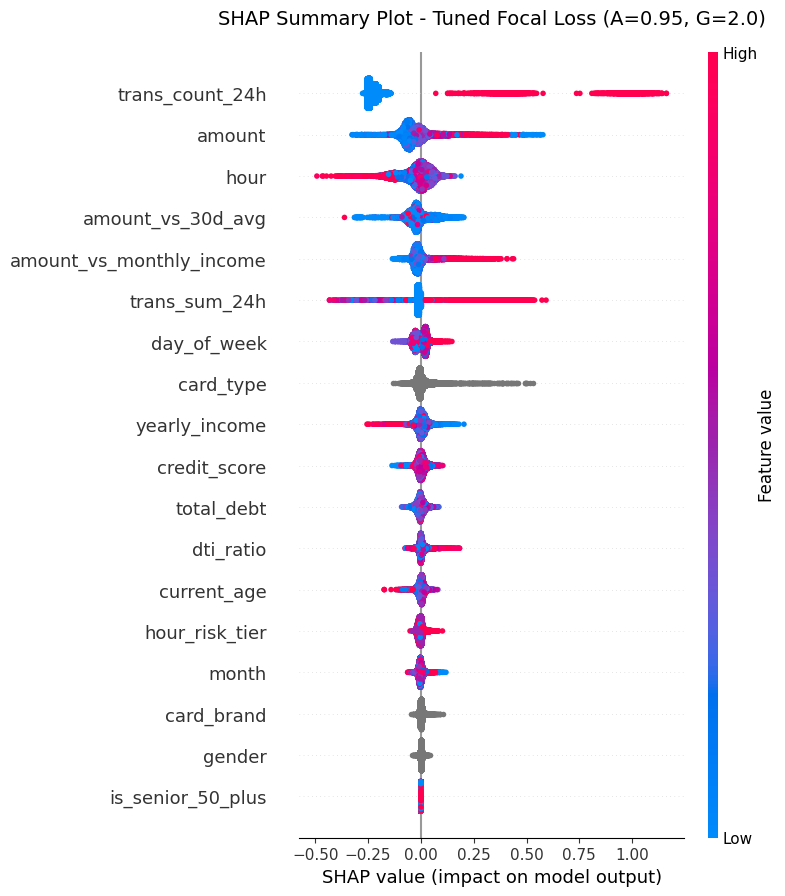

In [20]:
explainer = shap.TreeExplainer(best_focal_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8)) 
shap.summary_plot(shap_values, X_test, show=False)
plt.title(f"SHAP Summary Plot - Tuned Focal Loss (A={best_alpha}, G={best_gamma})", fontsize=14, pad=20)
plt.show()

CHẤT LƯỢNG MÔ HÌNH TẠI NGƯỠNG TỐI ƯU (Threshold = 0.79)

              precision    recall  f1-score   support

           0     0.9638    0.9251    0.9441     19360
           1     0.5787    0.7477    0.6525      2664

    accuracy                         0.9037     22024
   macro avg     0.7713    0.8364    0.7983     22024
weighted avg     0.9173    0.9037    0.9088     22024



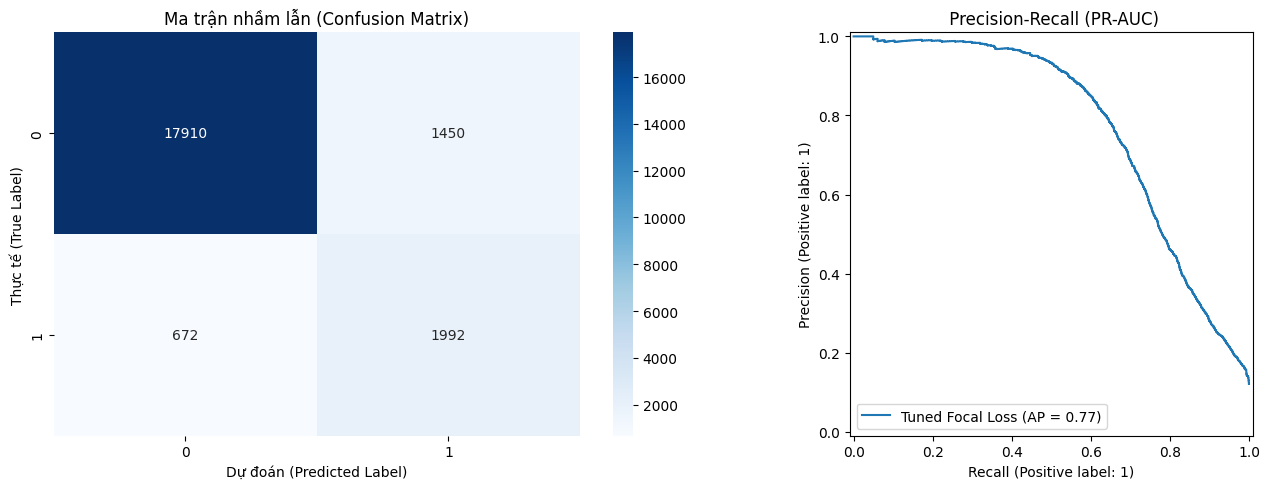

BUSINESS IMPACT
1. Tổng giá trị gian lận trong tập Test:     $287,190.17
2. Số tiền mô hình BẢO VỆ ĐƯỢC (Bắt trúng):  $250,101.30 (87.1%)
3. Chi phí phạt do khóa nhầm thẻ (Chịu lỗ):  $14,500.00
   => LỢI NHUẬN RÒNG MÔ HÌNH MANG LẠI:       $235,601.30


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, PrecisionRecallDisplay

y_pred_optimal = (y_prob_best >= best_threshold).astype(int)

print(f"CHẤT LƯỢNG MÔ HÌNH TẠI NGƯỠNG TỐI ƯU (Threshold = {best_threshold:.2f})\n")
print(classification_report(y_test, y_pred_optimal, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Ma trận nhầm lẫn (Confusion Matrix)')
axes[0].set_ylabel('Thực tế (True Label)')
axes[0].set_xlabel('Dự đoán (Predicted Label)')

PrecisionRecallDisplay.from_predictions(y_test, y_prob_best, ax=axes[1], name='Tuned Focal Loss')
axes[1].set_title(' Precision-Recall (PR-AUC)')

plt.tight_layout()
plt.show()

total_fraud_amount = np.sum(amounts[y_test == 1])
fraud_caught_amount = np.sum(amounts[(y_pred_optimal == 1) & (y_test == 1)])
false_positive_cost = np.sum((y_pred_optimal == 1) & (y_test == 0)) * COST_FP
net_value = fraud_caught_amount - false_positive_cost


print("BUSINESS IMPACT")

print(f"1. Tổng giá trị gian lận trong tập Test:     ${total_fraud_amount:,.2f}")
print(f"2. Số tiền mô hình BẢO VỆ ĐƯỢC (Bắt trúng):  ${fraud_caught_amount:,.2f} ({fraud_caught_amount/total_fraud_amount*100:.1f}%)")
print(f"3. Chi phí phạt do khóa nhầm thẻ (Chịu lỗ):  ${false_positive_cost:,.2f}")
print(f"   => LỢI NHUẬN RÒNG MÔ HÌNH MANG LẠI:       ${net_value:,.2f}")
